In [384]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud

In [385]:
sns.set_theme(style="whitegrid", palette="Blues_r",)
sns.set_palette(["#87CEEB"])  # globalize sky blue fill

In [386]:
df = pd.read_csv(r"../data/processed/processed.csv")

In [387]:
df.Post_ID.unique().size 

100

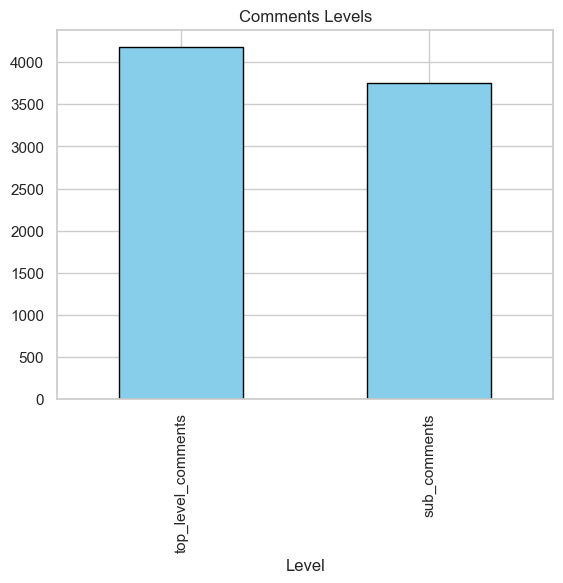

In [388]:

df.Level.value_counts().plot(kind='bar', title='Comments Levels', edgecolor='black')
plt.xticks(ticks=[0, 1], labels=['top_level_comments', 'sub_comments'])
plt.show()

### Preprocessing.
1. Columns like Post_Title, Comment_ID, Parent_ID, Author, Level, Sentiment_Score & Confidence as no value withrespect to given problem stmt. 
2. Body is droped since we have processed body feature as text_clean.
3. Score is renamed as upvotes.


In [389]:
df.drop(columns=['Post_ID', 'Post_Title', 'Comment_ID', 'Parent_ID', 'Author','Confidence', 'Sentiment_Score', 'Body'], inplace=True)

In [390]:
df.rename(columns={'Score': 'upvotes', 'Sentiment':'sentiment'}, inplace=True)

#### Dataset Findings.
1. 100 uniques posts data.
2. There are 4000 top level posts and 3500 sublevel posts. 
3. Imbalanced data - negative class is dominating than postive.

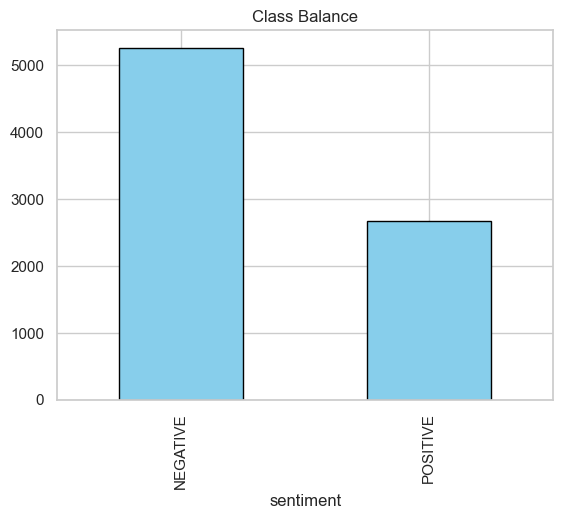

In [391]:
df['sentiment'].value_counts().plot(kind='bar', title='Class Balance', edgecolor='black')
plt.savefig(r'../reports/class.png')
plt.show()

<Axes: title={'center': 'Total upvotes sum for postive and negative sentiment'}, xlabel='sentiment'>

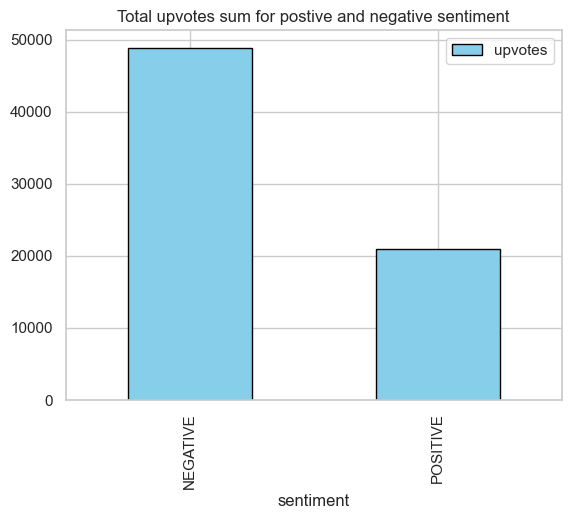

In [392]:

pd.pivot_table(data=df, index='sentiment', values='upvotes', aggfunc='sum').plot(kind='bar', title="Total upvotes sum for postive and negative sentiment", edgecolor='black')


Negative class comments has many upvotes then the postive this could also be due to the fact the negative class has many datapoints than the postive class due to clas imbalance 

In [393]:
upvotes = pd.Series({
    'pos_upvotes': (df['upvotes'] >= 1).count(),
    'neg_upvotes': (df['upvotes'] < 0).count(),
    'zero_upvotes': (df['upvotes'] == 0).count()
})

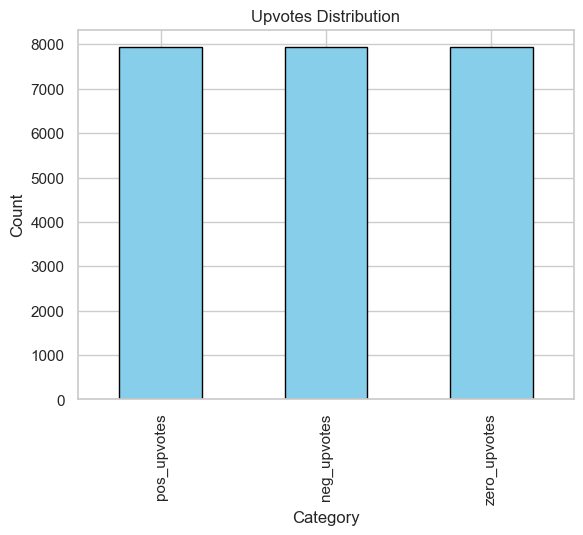

In [394]:
upvotes.plot(kind='bar', edgecolor='black')

plt.title("Upvotes Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

if we look at the graph we can understand that there is uniform dist of the pos, neg and zero upvotes.

In [395]:
df['upvotes'].describe()

count    7932.000000
mean        8.791730
std       108.265777
min      -105.000000
25%         1.000000
50%         1.000000
75%         3.000000
max      5902.000000
Name: upvotes, dtype: float64

<Axes: >

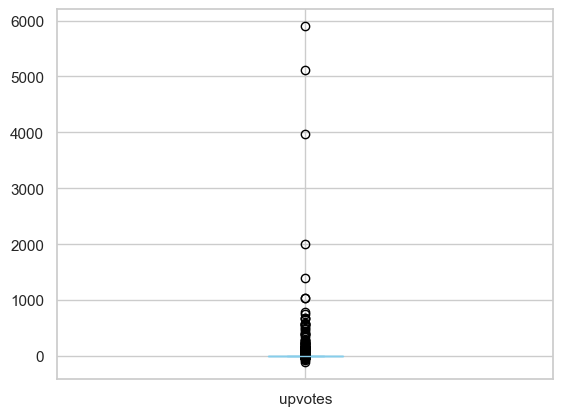

In [396]:
df['upvotes'].plot(kind='box')

massive outliers in the upvotes column

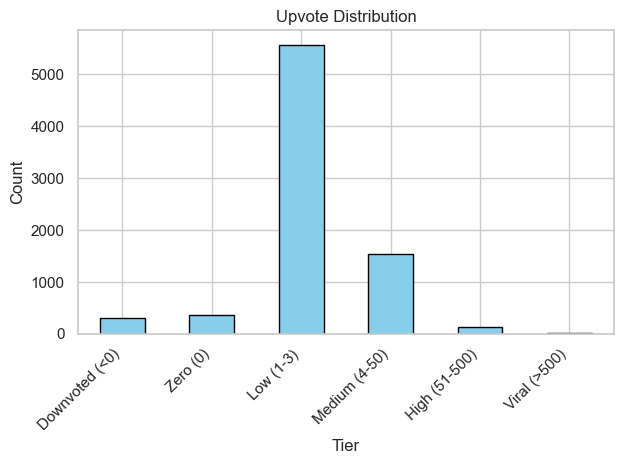

In [397]:
bins   = [-106, 0, 1, 4, 51, 501, 5903]
labels = ['Downvoted (<0)', 'Zero (0)', 'Low (1-3)', 'Medium (4-50)', 'High (51-500)', 'Viral (>500)']

df['upvote_tier'] = pd.cut(df['upvotes'], bins=bins, labels=labels, right=False)

df['upvote_tier'].value_counts().reindex(labels).plot(kind='bar', edgecolor='black')

plt.title('Upvote Distribution')
plt.xlabel('Tier')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

we can understand that the they are many comments which are having 1-3 upvotes and very few comments got viral.

In [398]:
lwdf = df.groupby(['Level','upvote_tier'])['upvotes'].count().reset_index()

lwdf['Level'] = lwdf['Level'].map({
    0: 'top_level_comments',
    1: 'sub_comments'
})

C:\Users\nkrahul\AppData\Local\Temp\ipykernel_7844\3964680138.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lwdf = df.groupby(['Level','upvote_tier'])['upvotes'].count().reset_index()


In [399]:
pivot = lwdf.pivot(index='Level', columns='upvote_tier', values='upvotes')


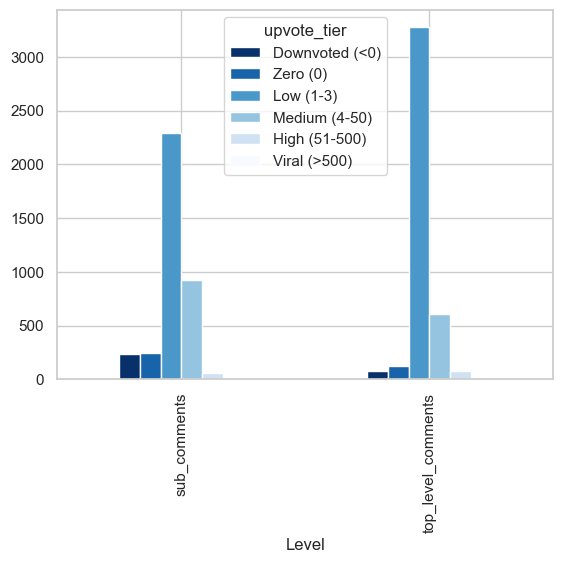

In [400]:
pivot.plot(kind='bar', colormap='Blues_r')
plt.savefig("../reports/upvotes_tier.png")
plt.show()

Overall we can see that (4-50) upvotes for sub comments are higher meaning users gave upvotes for most of the subcomments to the post and also we can also see that most of the user sub comments are also downvoted meaning not agreeing with comment and top level parent comments has very less down votes meaning most of the comments user posted to the post are not disagreeing and we can see that most parent comments are having 1-3 upvotes.

Generally we see that sub_comments are usally lesser in the number even then they are matching with parent level comments.


we can conclude that users are mostly aggreeing with comments posted. 


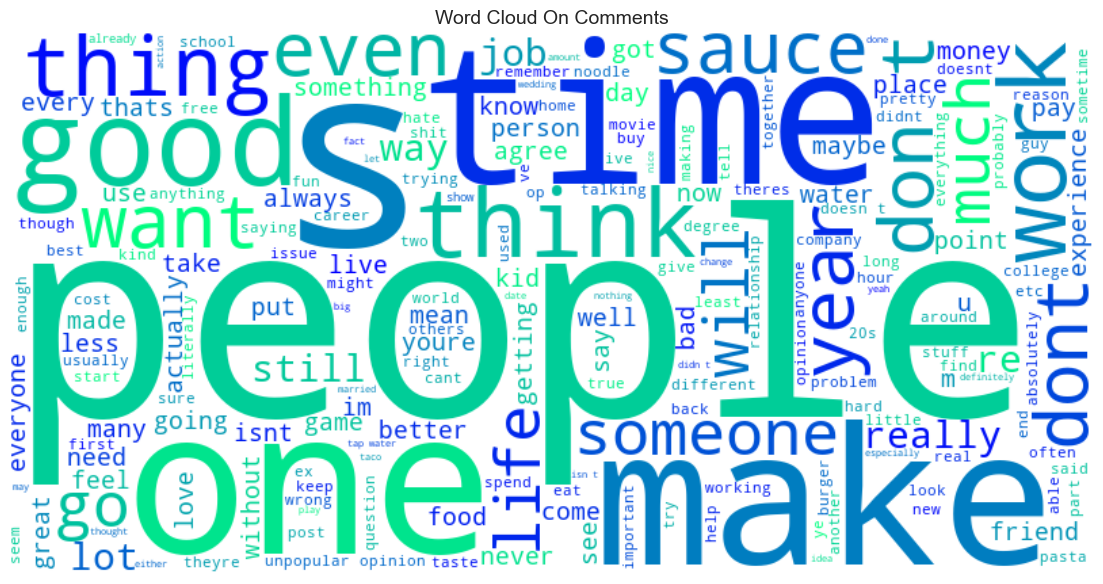

In [401]:
wordcloud = WordCloud(
    background_color='white',
    colormap='winter',
    width=800,
    height=400
).generate(''.join(df['text_clean']))

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud On Comments', fontsize=14)
plt.tight_layout()
plt.savefig(r"../reports/comments_wordcloud_org.png")
plt.show()

Since i wanted multilevel classification for some other dataset i'm adding the neutral sentiment data as well.

In [402]:
import os
import tempfile

import kagglehub
from kagglehub import KaggleDatasetAdapter

dataset_path = ''
data:pd.DataFrame = pd.DataFrame()
with tempfile.TemporaryDirectory() as tmp_dir:  
        dataset_path = kagglehub.dataset_download('cosmos98/twitter-and-reddit-sentimental-analysis-dataset', output_dir=tmp_dir)
         
        files  = os.listdir(dataset_path)
        csv_file = [f for f in files if f.endswith(".csv")]

        if not csv_file:
            raise FileNotFoundError("No file found in dataset")

        file_path = os.path.join(dataset_path, csv_file[0])

        
        data = pd.read_csv(file_path)

100%|██████████| 10.0M/10.0M [00:03<00:00, 3.33MB/s]

Extracting files...


In [403]:
df['sentiment'].value_counts()

sentiment
NEGATIVE    5261
POSITIVE    2671
Name: count, dtype: int64

In [404]:
sample_df = data[data['category'] == 0].sample(2671)

In [405]:
sample_df.rename(columns={'category':'sentiment'}, inplace=True)

In [406]:
df['sentiment'] = df['sentiment'].map(lambda x: -1 if x == 'NEGATIVE' else 1)

In [407]:
import re
import string


def clean_text(text: str) -> str | None:
    """
    Stage 1 cleaning (pre-EDA):
      - Removes URLs, Reddit markdown, mentions, hashtags
      - Removes punctuation
      - Lowercases & collapses whitespace
      - Drops texts shorter than 10 chars (no sentiment signal)
    """
    if not isinstance(text, str):
        return None

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove Reddit-specific formatting
    text = re.sub(r'\[.*?\]\(.*?\)', '', text)  # [text](url) markdown links
    text = re.sub(r'&gt;.*?\n', '', text)        # quoted text (>)
    text = re.sub(r'r/\w+|u/\w+', '', text)     # subreddit/user mentions

    # Remove mentions and hashtags
    text = re.sub(r'[@#]\w+', '', text)

    # Remove punctuation (keeps alphanumerics + spaces)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Collapse whitespace + lowercase
    text = re.sub(r'\s+', ' ', text).strip().lower()

    return text if len(text) >= 10 else None

In [408]:
import emoji


def deemojize(text:str):
    if isinstance(text, str) and len(text) > 0:
        return emoji.demojize(text)
    else:
        return None

In [409]:
sample_df['text_clean'] = sample_df['clean_comment'].apply(clean_text)


In [410]:
sample_df.drop(columns=['clean_comment'], inplace=True)

In [411]:
sample_df['text_clean'] = sample_df['text_clean'].apply(deemojize)

In [417]:
sample_df = sample_df[sample_df['text_clean'].notna()]

In [421]:
final_df = pd.concat([df.loc[:, ['sentiment', 'text_clean']], sample_df])

In [425]:
final_df.to_csv(r'../data/processed/dataset.csv', index=False)